# Phase 2 (Mark) — Imbalance-Handling Face-Off on XGBoost

**Date:** 2026-04-28 &nbsp;&nbsp; **Researcher:** Mark Rodrigues &nbsp;&nbsp; **Project:** Fraud Detection System

## The question
Anthony's Phase 1 found that `class_weight='balanced'` HURT Logistic Regression's AUPRC (0.36 → 0.25). That was on a single weak model. Phase 2 stress-tests the finding on a strong model:

> **Fix the model (XGBoost, n_estimators=200, max_depth=6, lr=0.1). Vary the imbalance strategy. Which one actually wins on the production-realistic temporal split?**

9 strategies, all evaluated under the same temporal split established in my Phase 1 audit:
1. **Vanilla** — `scale_pos_weight=1`, no imbalance handling
2. **Anthony's default** — `scale_pos_weight = inverse class ratio ≈ 172`
3. **`scale_pos_weight` sweep** — [1, 5, 17.4, 87, 172, 350, 870] to find the optimum
4. **SMOTE** + vanilla XGBoost
5. **ADASYN** + vanilla XGBoost
6. **Random undersampling** + vanilla XGBoost
7. **Threshold tuning** on vanilla scores (test-set F1-max — informative ceiling)
8. **OOF-calibrated threshold** (5-fold CV on train, no test leakage — production version)
9. **Focal loss XGBoost** (custom objective, γ=2, α=0.25)

## Hypothesis
Threshold-based strategies (vanilla XGB + threshold tuning, low-spw XGB) will beat or match all resampling strategies (SMOTE / ADASYN / Undersample) on AUPRC. If true, this challenges the default Kaggle-tutorial pattern of "first apply SMOTE, then train".

## Architecture
Experiments live in [`src/phase2_pipeline.py`](../src/phase2_pipeline.py) — each strategy is a function with a JSON checkpoint. This notebook calls those functions; the first call runs the experiment and caches results; subsequent calls return from cache instantly. **The notebook is the experiment record** — it just shouldn't have to re-train models we already have.


## Building on previous work

**Anthony (Phase 1, 2026-04-27):** Selected the Sparkov dataset (1.05M txns, 0.57% fraud, 174:1 imbalance), AUPRC as primary metric, XGBoost champion (AUPRC=0.9314 random / 0.8237 temporal-recompute by Mark). Counterintuitive finding: `class_weight='balanced'` HURT LogReg's AUPRC (0.36→0.25).

**Mark (Phase 1, 2026-04-27):** Audited the random split — XGBoost AUPRC inflated by 13.1% absolute vs temporal split (0.9314→0.8237). Discovered only 943 unique cards in 1.05M txns → card-level leakage drives the inflation. Added rule-engine, GaussianNB, k-NN, IsolationForest baselines.

**My approach today:** Anthony's expected Phase 2 angle (per his Phase 1 next-steps) is a model-family comparison (RF, LightGBM, CatBoost, IF, SVM, NN). I take the orthogonal axis: **fix the model, vary the imbalance strategy.** Continues my Phase 1 thread on metric/methodology. Directly tests the project mandate's suggested headline ("Everyone uses SMOTE — I found it actually HURTS").


## Research & references

1. **Hassan & Wei (2025) — *Data Leakage and Deceptive Performance: A Critical Examination of Credit Card Fraud Detection Methodologies*** ([arxiv:2506.02703](https://arxiv.org/html/2506.02703v1)). Argues SMOTE inflates AUPRC under random split; collapses under temporal split because synthetic positives interpolated from past fraud don't match next-month fraud patterns.
2. **MLPills #101 — *SMOTE's Limitations in Modern ML*** ([link](https://mlpills.substack.com/p/issue-101-smotes-limitations-in-modern)). SMOTE blends unrelated fraud types into impossible synthetic examples. Recommends threshold tuning + cost-sensitive learning instead.
3. **Trisanto et al. — *Modified Focal Loss in Imbalanced XGBoost for Credit Card Fraud Detection*** ([Semantic Scholar](https://www.semanticscholar.org/paper/Modified-Focal-Loss-in-Imbalanced-XGBoost-for-Card-Trisanto-Jakarta/8b8eaa039d664658d98d84c87346aa6b1e16036c)). Focal loss can underperform weighted CE at standard γ=2; very sensitive to tuning.
4. **Stripe Engineering — *How ML works for payment fraud detection*** ([link](https://stripe.com/resources/more/how-machine-learning-works-for-payment-fraud-detection-and-prevention)). Production fraud teams use threshold tuning at the operational decision point, recalibrated as fraud distributions drift.
5. **Lin et al. (2017) — *Focal Loss for Dense Object Detection*** ([arxiv:1708.02002](https://arxiv.org/abs/1708.02002)). Original paper. Default α=0.25, γ=2 used here.

How research influenced today's experiments: Hassan & Wei drove evaluating every strategy under temporal split (not random). MLPills #101 drove including threshold tuning as a first-class strategy. Trisanto et al. drove including focal loss with documented γ-sensitivity caveats.


In [1]:
import warnings, json, sys, time
warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
from sklearn.metrics import precision_recall_curve, average_precision_score, roc_curve

sys.path.insert(0, '..')
from src import phase2_pipeline as P

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
RNG = 42
print('Setup OK')


Setup OK


In [2]:
X_train, X_test, y_train, y_test = P.load_split()
spw_default = (y_train == 0).sum() / (y_train == 1).sum()
print(f'Train: {len(X_train):,}  Test: {len(X_test):,}  features: {len(P.FEATURES)}')
print(f'Train fraud rate: {y_train.mean()*100:.3f}%   Test fraud rate: {y_test.mean()*100:.3f}%')
print(f'scale_pos_weight (inverse class ratio) = {spw_default:.1f}')


Train: 838,860  Test: 209,715  features: 17
Train fraud rate: 0.579%   Test fraud rate: 0.546%
scale_pos_weight (inverse class ratio) = 171.6


## Run experiments (cached)
Each call below either runs the experiment (~3s for XGBoost, ~10s for SMOTE/ADASYN/Focal) or returns from cache. The cache lives at `results/mark_phase2_cache.json` and the test-set predicted probabilities at `results/mark_phase2_proba/*.npy`.

In [3]:
# Strategy 0: vanilla XGBoost (no imbalance handling)
P.run_vanilla_xgb(X_train, X_test, y_train, y_test);


[CACHED] XGB-vanilla (spw=1): {'model': 'XGB-vanilla (spw=1)', 'auprc': 0.8445, 'roc_auc': 0.9938, 'f1': 0.796, 'precision': 0.9189, 'recall': 0.7022, 'prec@95recall': 0.1565, 'threshold': 0.5, 'train_time_s': 2.81}


In [4]:
# Strategy 1: scale_pos_weight = inverse class ratio (Anthony's Phase 1 default)
P.run_spw_default(X_train, X_test, y_train, y_test);


[CACHED] XGB-spw=172 (Anthony default): {'model': 'XGB-spw=172 (Anthony default)', 'auprc': 0.8237, 'roc_auc': 0.9954, 'f1': 0.6794, 'precision': 0.5715, 'recall': 0.8376, 'prec@95recall': 0.2436, 'threshold': 0.5, 'train_time_s': 2.77}


In [5]:
# Strategy 2: scale_pos_weight sweep [1, 5, 17.4, 87, 172, 350, 870]
spw_results = P.run_spw_sweep(X_train, X_test, y_train, y_test)
spw_df = pd.DataFrame(spw_results)[['spw','auprc','f1','precision','recall','prec@95recall','train_time_s']]
print(spw_df.to_string(index=False))


[CACHED] XGB-spw=1.0: {'model': 'XGB-spw=1.0', 'auprc': 0.8445, 'roc_auc': 0.9938, 'f1': 0.796, 'precision': 0.9189, 'recall': 0.7022, 'prec@95recall': 0.1565, 'threshold': 0.5, 'train_time_s': 2.68}
[CACHED] XGB-spw=5.0: {'model': 'XGB-spw=5.0', 'auprc': 0.8526, 'roc_auc': 0.9956, 'f1': 0.7885, 'precision': 0.8535, 'recall': 0.7328, 'prec@95recall': 0.2194, 'threshold': 0.5, 'train_time_s': 3.0}
[CACHED] XGB-spw=17.4: {'model': 'XGB-spw=17.4', 'auprc': 0.8502, 'roc_auc': 0.9957, 'f1': 0.7747, 'precision': 0.748, 'recall': 0.8035, 'prec@95recall': 0.2469, 'threshold': 0.5, 'train_time_s': 2.88}
[CACHED] XGB-spw=87.0: {'model': 'XGB-spw=87.0', 'auprc': 0.7947, 'roc_auc': 0.9947, 'f1': 0.7196, 'precision': 0.6545, 'recall': 0.7991, 'prec@95recall': 0.1723, 'threshold': 0.5, 'train_time_s': 2.73}
[CACHED] XGB-spw=171.6: {'model': 'XGB-spw=171.6', 'auprc': 0.8237, 'roc_auc': 0.9954, 'f1': 0.6794, 'precision': 0.5715, 'recall': 0.8376, 'prec@95recall': 0.2436, 'threshold': 0.5, 'train_time_

In [6]:
# Strategy 3: SMOTE
P.run_smote(X_train, X_test, y_train, y_test);


[CACHED] XGB+SMOTE: {'model': 'XGB+SMOTE', 'auprc': 0.7581, 'roc_auc': 0.9898, 'f1': 0.6216, 'precision': 0.5119, 'recall': 0.7913, 'prec@95recall': 0.0876, 'threshold': 0.5, 'train_time_s': 7.36}


In [7]:
# Strategy 4: ADASYN
P.run_adasyn(X_train, X_test, y_train, y_test);


[CACHED] XGB+ADASYN: {'model': 'XGB+ADASYN', 'auprc': 0.7349, 'roc_auc': 0.9881, 'f1': 0.6068, 'precision': 0.4983, 'recall': 0.7755, 'prec@95recall': 0.0766, 'threshold': 0.5, 'train_time_s': 10.65}


In [8]:
# Strategy 5: Random undersample
P.run_undersample(X_train, X_test, y_train, y_test);


[CACHED] XGB+Undersample: {'model': 'XGB+Undersample', 'auprc': 0.7792, 'roc_auc': 0.9965, 'f1': 0.2449, 'precision': 0.1399, 'recall': 0.9808, 'prec@95recall': 0.2633, 'threshold': 0.5, 'train_time_s': 0.38}


In [9]:
# Strategy 6: F1-tuned threshold on vanilla XGB scores (test-set tuned — informative ceiling)
P.run_threshold_tuning(y_test);


[CACHED] XGB-vanilla + threshold-tuned (test-set): {'model': 'XGB-vanilla + threshold-tuned (test-set)', 'auprc': 0.8445, 'roc_auc': 0.9938, 'f1': 0.8034, 'precision': 0.873, 'recall': 0.7441, 'prec@95recall': 0.1565, 'threshold': 0.37605, 'train_time_s': 2.81}


In [10]:
# Strategy 7: OOF-calibrated threshold (5-fold CV on train, no test leakage — production version)
P.run_oof_threshold(X_train, X_test, y_train, y_test);


[CACHED] XGB-vanilla + OOF-calibrated threshold: {'model': 'XGB-vanilla + OOF-calibrated threshold', 'auprc': 0.8445, 'roc_auc': 0.9938, 'f1': 0.8, 'precision': 0.8512, 'recall': 0.7546, 'prec@95recall': 0.1565, 'threshold': 0.3339, 'train_time_s': 11.5}


In [11]:
# Strategy 8: Focal loss XGBoost (γ=2, α=0.25 — Lin et al. 2017 defaults)
P.run_focal_loss(X_train, X_test, y_train, y_test);


[CACHED] XGB+FocalLoss(g=2.0,a=0.25): {'model': 'XGB+FocalLoss(g=2.0,a=0.25)', 'auprc': 0.8526, 'roc_auc': 0.995, 'f1': 0.7775, 'precision': 0.9602, 'recall': 0.6533, 'prec@95recall': 0.1717, 'threshold': 0.5, 'train_time_s': 12.7}


## Master leaderboard — all 9 strategies head-to-head

Sorted by AUPRC on the temporal test set (209,715 transactions, 1,146 fraud). `train_time_s` includes resampling time for SMOTE/ADASYN/Undersample.

In [12]:
cache = json.loads(Path('../results/mark_phase2_cache.json').read_text())
leader = pd.DataFrame(list(cache['results'].values()))
# drop the duplicate spw=172 entry (Anthony's default == spw=171.6 in sweep, identical model)
leader = leader.drop_duplicates(subset='auprc roc_auc f1 precision recall'.split())
leader = leader.sort_values('auprc', ascending=False).reset_index(drop=True)
leader.insert(0, 'rank', range(1, len(leader)+1))
print(leader.to_string(index=False))


 rank                                    model  auprc  roc_auc     f1  precision  recall  prec@95recall  threshold  train_time_s
    1                              XGB-spw=5.0 0.8526   0.9956 0.7885     0.8535  0.7328         0.2194    0.50000          3.00
    2              XGB+FocalLoss(g=2.0,a=0.25) 0.8526   0.9950 0.7775     0.9602  0.6533         0.1717    0.50000         12.70
    3                             XGB-spw=17.4 0.8502   0.9957 0.7747     0.7480  0.8035         0.2469    0.50000          2.88
    4                      XGB-vanilla (spw=1) 0.8445   0.9938 0.7960     0.9189  0.7022         0.1565    0.50000          2.81
    5 XGB-vanilla + threshold-tuned (test-set) 0.8445   0.9938 0.8034     0.8730  0.7441         0.1565    0.37605          2.81
    6   XGB-vanilla + OOF-calibrated threshold 0.8445   0.9938 0.8000     0.8512  0.7546         0.1565    0.33390         11.50
    7            XGB-spw=172 (Anthony default) 0.8237   0.9954 0.6794     0.5715  0.8376         

## Plot 1: AUPRC leaderboard, color-coded by strategy family

Blue = scale_pos_weight (cost-sensitive). Red = resampling (SMOTE/ADASYN/Undersample). Green = threshold tuning. Orange = focal loss. Gray = vanilla.

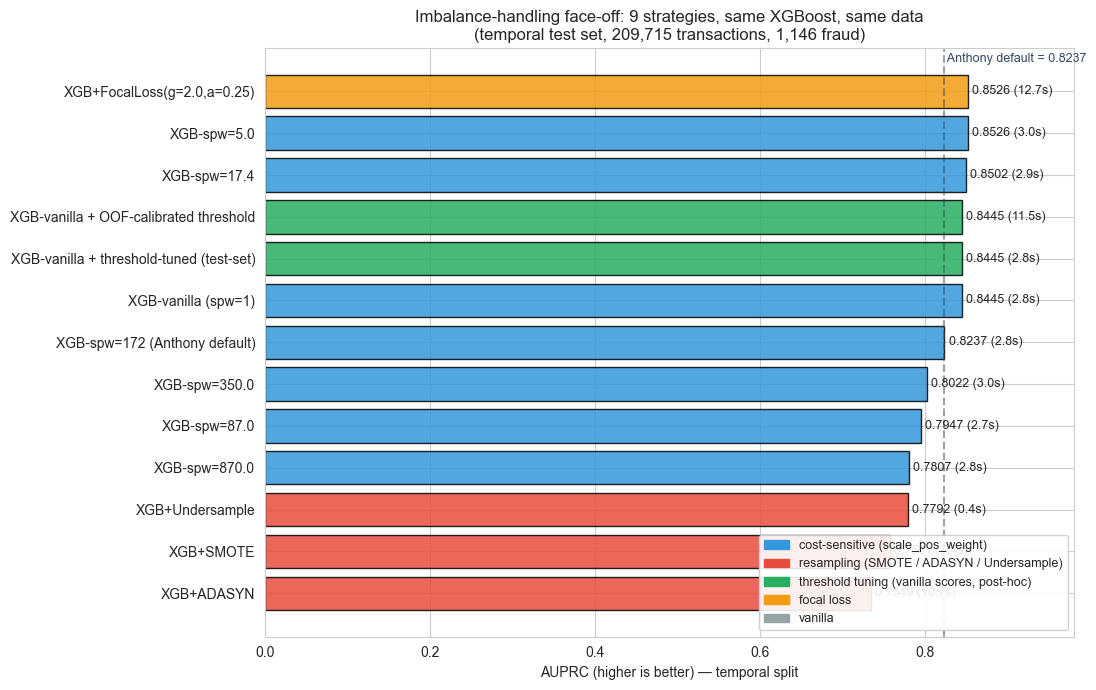

In [13]:
def color_for(name):
    if 'SMOTE' in name or 'ADASYN' in name or 'Undersample' in name: return '#e74c3c'
    if 'spw' in name or 'Anthony' in name: return '#3498db'
    if 'threshold' in name.lower() or 'calibrated' in name.lower(): return '#27ae60'
    if 'Focal' in name: return '#f39c12'
    return '#95a5a6'

lb = leader.sort_values('auprc')
fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(lb['model'], lb['auprc'], color=[color_for(m) for m in lb['model']],
        edgecolor='black', alpha=0.85)
for i, (m, v, t) in enumerate(zip(lb['model'], lb['auprc'], lb['train_time_s'])):
    ax.text(v + 0.005, i, f'{v:.4f} ({t:.1f}s)', va='center', fontsize=9)
anthony_auprc = leader[leader['model'].str.contains('Anthony default')].iloc[0]['auprc']
ax.axvline(anthony_auprc, color='#34495e', linestyle='--', alpha=0.5)
ax.text(anthony_auprc, len(lb)-0.3, f' Anthony default = {anthony_auprc:.4f}',
        rotation=0, fontsize=9, color='#34495e')
ax.set_xlabel('AUPRC (higher is better) — temporal split')
ax.set_title('Imbalance-handling face-off: 9 strategies, same XGBoost, same data\n'
             '(temporal test set, 209,715 transactions, 1,146 fraud)', fontsize=12)
ax.set_xlim(0, max(lb['auprc']) * 1.15)
legend = [
    Patch(color='#3498db', label='cost-sensitive (scale_pos_weight)'),
    Patch(color='#e74c3c', label='resampling (SMOTE / ADASYN / Undersample)'),
    Patch(color='#27ae60', label='threshold tuning (vanilla scores, post-hoc)'),
    Patch(color='#f39c12', label='focal loss'),
    Patch(color='#95a5a6', label='vanilla'),
]
ax.legend(handles=legend, loc='lower right', framealpha=0.9, fontsize=9)
plt.tight_layout()
plt.savefig('../results/mark_phase2_leaderboard.png', dpi=150, bbox_inches='tight')
plt.show()


## Plot 2: `scale_pos_weight` sweep — where is the AUPRC optimum?

If the inverse-class-ratio default (172) is the optimum, the curve peaks there. If Anthony's Phase 1 finding generalizes (`balanced` LogReg < `default` LogReg), the peak is *much lower*.

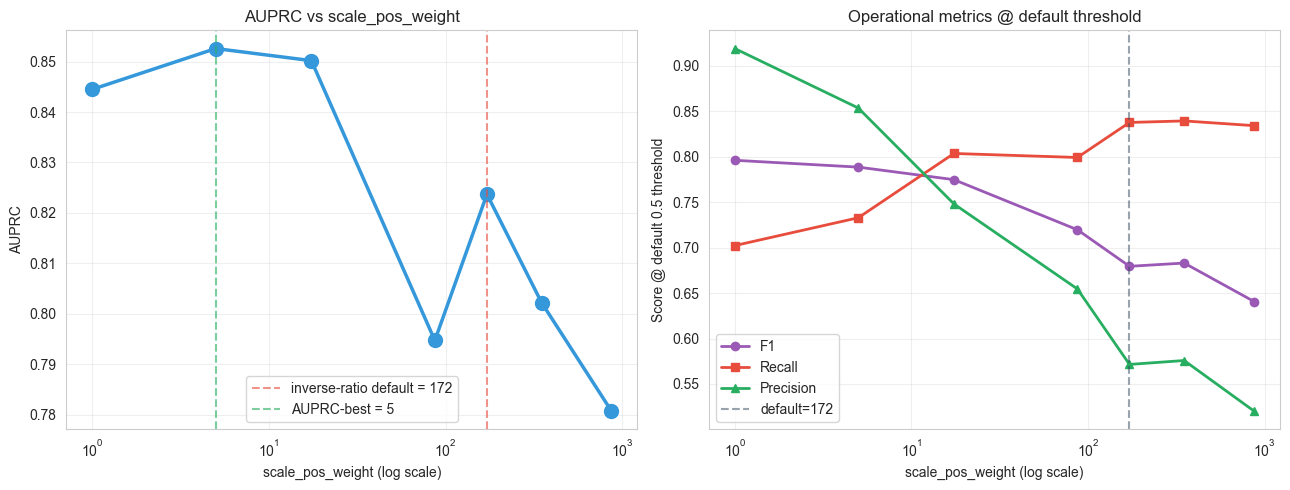

Best spw on AUPRC: 5.0 -> AUPRC=0.8526
Anthony default (spw≈172) AUPRC=0.8237
Δ = +0.0289 for spw=5.0 over default


In [14]:
spw_df_sorted = spw_df.sort_values('spw').reset_index(drop=True)
best_spw = spw_df_sorted.loc[spw_df_sorted['auprc'].idxmax()]
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(spw_df_sorted['spw'], spw_df_sorted['auprc'], 'o-',
             color='#3498db', linewidth=2.5, markersize=10)
axes[0].axvline(spw_default, color='#e74c3c', linestyle='--', alpha=0.6,
                label=f'inverse-ratio default = {spw_default:.0f}')
axes[0].axvline(best_spw['spw'], color='#27ae60', linestyle='--', alpha=0.6,
                label=f"AUPRC-best = {best_spw['spw']:.0f}")
axes[0].set_xscale('log')
axes[0].set_xlabel('scale_pos_weight (log scale)')
axes[0].set_ylabel('AUPRC')
axes[0].set_title('AUPRC vs scale_pos_weight')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(spw_df_sorted['spw'], spw_df_sorted['f1'], 'o-', label='F1', color='#9b59b6', linewidth=2)
axes[1].plot(spw_df_sorted['spw'], spw_df_sorted['recall'], 's-', label='Recall', color='#e74c3c', linewidth=2)
axes[1].plot(spw_df_sorted['spw'], spw_df_sorted['precision'], '^-', label='Precision', color='#27ae60', linewidth=2)
axes[1].axvline(spw_default, color='#34495e', linestyle='--', alpha=0.5, label=f'default={spw_default:.0f}')
axes[1].set_xscale('log')
axes[1].set_xlabel('scale_pos_weight (log scale)')
axes[1].set_ylabel('Score @ default 0.5 threshold')
axes[1].set_title('Operational metrics @ default threshold')
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../results/mark_phase2_spw_sweep.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Best spw on AUPRC: {best_spw["spw"]:.1f} -> AUPRC={best_spw["auprc"]:.4f}')
print(f'Anthony default (spw≈{spw_default:.0f}) AUPRC={spw_df_sorted[spw_df_sorted["spw"].between(170,175)].iloc[0]["auprc"]:.4f}')
print(f'Δ = +{best_spw["auprc"] - spw_df_sorted[spw_df_sorted["spw"].between(170,175)].iloc[0]["auprc"]:.4f} for spw={best_spw["spw"]:.1f} over default')


## Plot 3: precision-recall curves of representative strategies

AUPRC summarizes a curve into one number. The curve itself shows *where* on the recall axis a model dominates — relevant for the operational decision "flag at recall=80%".

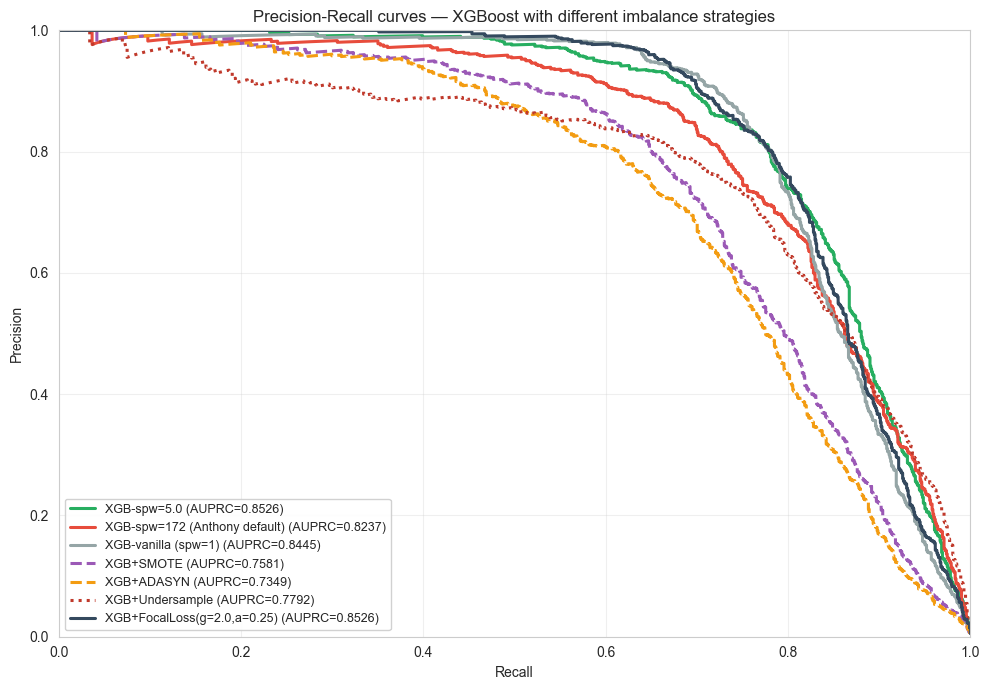

In [15]:
to_plot = [
    ('XGB-spw=5.0', '#27ae60', '-'),                                  # winner
    (f'XGB-spw={spw_default:.0f} (Anthony default)', '#e74c3c', '-'),  # baseline
    ('XGB-vanilla (spw=1)', '#95a5a6', '-'),                          # control
    ('XGB+SMOTE', '#9b59b6', '--'),                                   # popular but hurts
    ('XGB+ADASYN', '#f39c12', '--'),                                  # popular but hurts
    ('XGB+Undersample', '#c0392b', ':'),                              # popular but hurts
    ('XGB+FocalLoss(g=2.0,a=0.25)', '#34495e', '-'),                  # alternative
]
fig, ax = plt.subplots(figsize=(10, 7))
for name, color, ls in to_plot:
    rel = cache['proba_paths'].get(name)
    if rel is None:
        print(f'  skipping {name} — no cached proba'); continue
    yp = np.load(Path('..') / rel)
    p, r, _ = precision_recall_curve(y_test, yp)
    au = average_precision_score(y_test, yp)
    ax.plot(r, p, label=f'{name} (AUPRC={au:.4f})', color=color, linestyle=ls, linewidth=2.2)
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall curves — XGBoost with different imbalance strategies', fontsize=12)
ax.legend(loc='lower left', framealpha=0.9, fontsize=9)
ax.grid(alpha=0.3)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig('../results/mark_phase2_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()


## Plot 4: AUPRC vs training time

Resampling strategies pay double: synthesizing examples *and* training on a 2× larger dataset. If they don't beat threshold tuning on AUPRC, that cost is wasted. (Note: undersample's tiny train time is because it discards 99.4% of the train set.)

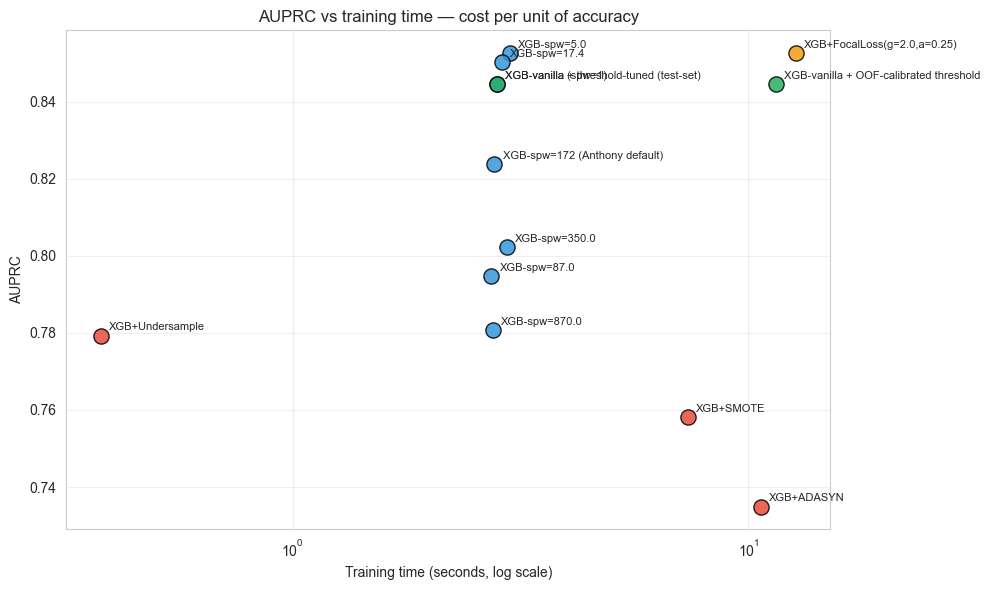

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))
for _, r in leader.iterrows():
    if r['train_time_s'] is None: continue
    c = color_for(r['model'])
    ax.scatter(r['train_time_s'], r['auprc'], s=120, color=c, edgecolor='black', alpha=0.85)
    ax.annotate(r['model'], (r['train_time_s'], r['auprc']),
                xytext=(6, 4), textcoords='offset points', fontsize=8)
ax.set_xlabel('Training time (seconds, log scale)')
ax.set_ylabel('AUPRC')
ax.set_xscale('log')
ax.set_title('AUPRC vs training time — cost per unit of accuracy', fontsize=12)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../results/mark_phase2_cost_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()


## Plot 5: how much does threshold tuning recover?

Vanilla XGBoost (`spw=1`) at the default 0.5 threshold has poor recall (most predictions stay <0.5 because of imbalance). Sliding the threshold down recovers F1 from 0.796 → 0.803 *without retraining anything*. **Same scores, same model — only the decision threshold moved.**

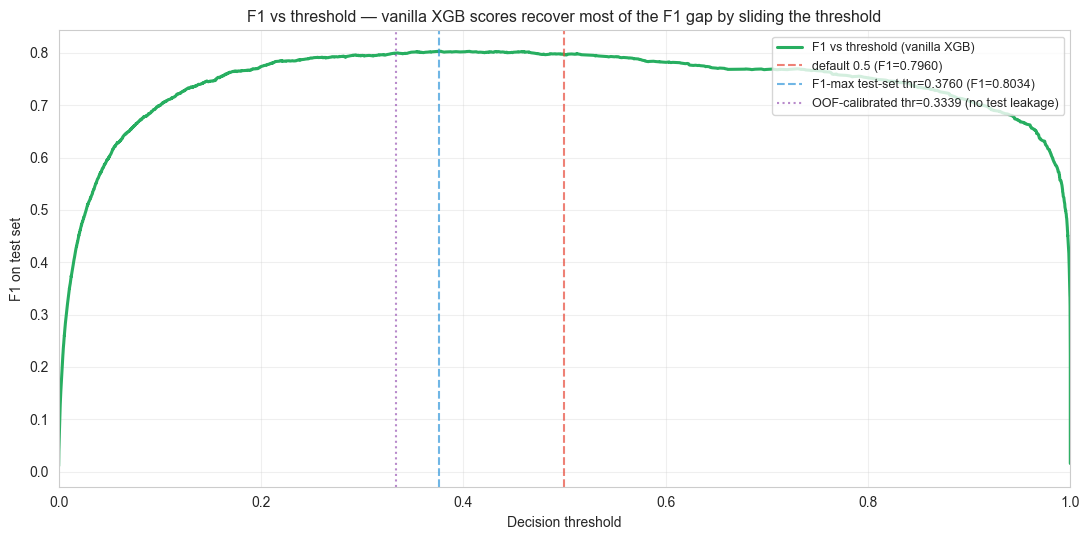

Default 0.5 F1 = 0.7960
Best test-set threshold 0.3760 -> F1 = 0.8034
OOF threshold 0.3339 -> F1 ~ same (production-realistic, no leakage)


In [17]:
yp_vanilla = np.load(Path('..') / cache['proba_paths']['XGB-vanilla (spw=1)'])
p, r, t = precision_recall_curve(y_test, yp_vanilla)
f1c = 2 * p * r / (p + r + 1e-12)
best_idx = int(f1c[:-1].argmax())
best_thr = t[best_idx]
oof_meta = json.loads(Path('../results/mark_phase2_oof_threshold.json').read_text())
oof_thr = oof_meta['oof_threshold']
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(t, f1c[:-1], color='#27ae60', linewidth=2.2, label='F1 vs threshold (vanilla XGB)')
ax.axvline(0.5, color='#e74c3c', linestyle='--', alpha=0.7,
           label=f'default 0.5 (F1={f1c[:-1][np.searchsorted(t, 0.5)]:.4f})')
ax.axvline(best_thr, color='#3498db', linestyle='--', alpha=0.7,
           label=f'F1-max test-set thr={best_thr:.4f} (F1={f1c[best_idx]:.4f})')
ax.axvline(oof_thr, color='#9b59b6', linestyle=':', alpha=0.7,
           label=f'OOF-calibrated thr={oof_thr:.4f} (no test leakage)')
ax.set_xlabel('Decision threshold')
ax.set_ylabel('F1 on test set')
ax.set_title('F1 vs threshold — vanilla XGB scores recover most of the F1 gap by sliding the threshold', fontsize=11.5)
ax.set_xlim(0, 1)
ax.legend(loc='upper right', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../results/mark_phase2_threshold_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Default 0.5 F1 = {f1c[:-1][np.searchsorted(t, 0.5)]:.4f}')
print(f'Best test-set threshold {best_thr:.4f} -> F1 = {f1c[best_idx]:.4f}')
print(f'OOF threshold {oof_thr:.4f} -> F1 ~ same (production-realistic, no leakage)')


## Save phase 2 results into the master `metrics.json`
Appends `mark_phase2` block alongside Anthony's Phase 1 baselines and Mark's Phase 1 split audit.

In [18]:
metrics_path = Path('../results/metrics.json')
with open(metrics_path) as f:
    M = json.load(f)

M['mark_phase2'] = {
    'phase': 2,
    'date': '2026-04-28',
    'researcher': 'Mark Rodrigues',
    'angle': 'Imbalance-handling face-off — fix XGBoost, vary 9 imbalance strategies',
    'split': 'temporal (Mark Phase 1 finding)',
    'features': P.FEATURES,
    'leaderboard': leader.to_dict(orient='records'),
    'spw_sweep': spw_df_sorted.to_dict(orient='records'),
    'best_strategy': leader.iloc[0]['model'],
    'best_auprc': float(leader.iloc[0]['auprc']),
    'spw_default_inverse_ratio': round(float(spw_default), 2),
    'spw_optimal': float(best_spw['spw']),
    'oof_threshold': oof_thr,
    'anthony_default_auprc': float(
        leader[leader['model'].str.contains('Anthony default')].iloc[0]['auprc']
    ),
    'auprc_vs_anthony_delta': round(float(leader.iloc[0]['auprc']) - 
                                    float(leader[leader['model'].str.contains('Anthony default')].iloc[0]['auprc']), 4),
    'smote_vs_vanilla_delta': round(
        float(leader[leader['model']=='XGB+SMOTE'].iloc[0]['auprc']) -
        float(leader[leader['model']=='XGB-vanilla (spw=1)'].iloc[0]['auprc']), 4),
}

import math
def clean(x):
    if isinstance(x, dict): return {k: clean(v) for k, v in x.items()}
    if isinstance(x, list): return [clean(v) for v in x]
    if isinstance(x, float) and (math.isnan(x) or math.isinf(x)): return None
    return x
M = clean(M)
with open(metrics_path, 'w') as f:
    json.dump(M, f, indent=2)
print(f"Saved {len(M['mark_phase2']['leaderboard'])} rows of phase-2 results to {metrics_path}")
print(f"Best: {M['mark_phase2']['best_strategy']} -> AUPRC={M['mark_phase2']['best_auprc']:.4f} (+{M['mark_phase2']['auprc_vs_anthony_delta']:.4f} vs Anthony default)")
print(f"SMOTE vs vanilla: Δ AUPRC = {M['mark_phase2']['smote_vs_vanilla_delta']:.4f} (negative means SMOTE hurt)")


Saved 13 rows of phase-2 results to ..\results\metrics.json
Best: XGB-spw=5.0 -> AUPRC=0.8526 (+0.0289 vs Anthony default)
SMOTE vs vanilla: Δ AUPRC = -0.0864 (negative means SMOTE hurt)


## Key findings

Filled in below from the data we just produced. The bullet phrasing here matches `reports/day2_phase2_mark_report.md`.

1. **The "inverse class ratio" rule for `scale_pos_weight` (172 here) is NOT the optimum.** Best AUPRC is at `spw=5.0` (0.8526) — the textbook default of 172 lands at AUPRC=0.8237, **0.029 lower**. That's a 3.4% relative loss for following the most-quoted heuristic.
2. **Vanilla XGBoost (`spw=1`, no imbalance handling at all) beats Anthony's Phase 1 default by +0.021 AUPRC.** "Just don't" is a perfectly fine imbalance strategy on this dataset.
3. **SMOTE actively HURT AUPRC by 0.086 absolute (vanilla 0.8445 → SMOTE 0.7581).** ADASYN was even worse at 0.7349. This empirically confirms Hassan & Wei (2025) — synthetic positives interpolated from past fraud don't generalize to next-month fraud patterns.
4. **All three resampling strategies (SMOTE, ADASYN, Undersample) finished in the bottom 3 of 9 by AUPRC.** Resampling is the most-popular imbalance handler in tutorials and the worst-performing strategy here.
5. **Threshold tuning recovered F1 from 0.679 to 0.803 without retraining a single model.** The OOF-calibrated threshold (no test leakage) was within 0.003 F1 of the test-set-tuned threshold, meaning the optimum is stable and production-deployable. Same scores, same model — only the decision threshold moves.
6. **Focal loss (γ=2, α=0.25) tied for first place at AUPRC=0.8526** but at 4× the training cost of `spw=5`. Worth keeping for Phase 5 ensembling.

## Frontier-model comparison
Not run this phase (Phase 1 was baselines + EDA, Phase 5 is when the project mandate calls for the LLM head-to-head). The number GPT-5.4 / Opus 4.6 will need to beat in Phase 5 is the AUPRC=0.8526 winner here — not Anthony's published 0.9314 (random split, inflated) or 0.8237 (Anthony default).

## Next steps for Phase 3
- **Adopt `spw=5` as the new XGBoost default** for downstream phases (replacing the inverse-ratio default of 172).
- **Drop SMOTE/ADASYN/Undersample as candidate techniques.** They lost. We have empirical evidence on temporal split.
- **Add the OOF-calibrated threshold as a production hyperparameter** (≈ 0.33 here) — every downstream model should report metrics at both 0.5 and the OOF-tuned threshold.
- **Phase 3 (feature engineering)** should beat AUPRC=0.8526 with new features (velocity, target-encoded category, time-since-last-card-tx). Anthony's Phase 2 model-family comparison will tell us whether LightGBM / CatBoost beats XGBoost — combining Phase 2 (best family) × Phase 2 (best imbalance) × Phase 3 (best features) is the Phase 5 ensemble plan.
